# Strategy comparison: 64x64 ResNet18 simulator-parameter search

This notebook compares `broad_random`, `latin_hypercube`, and `monte_carlo` as single-pass searches over simulator parameters for the binary fixation task `sigmoid` versus `no_class`. Candidate quality is judged by balanced accuracy on the real fixation validation set. The only CSV written by a successful run is `best_run.csv` for the best candidate across the three strategies.


In [1]:

# ============================================================================
# Imports, constants, and run configuration
# ============================================================================

import Pkg

ENV["JULIA_PKG_PRECOMPILE_AUTO"] = "0"
ENV["JULIA_NUM_PRECOMPILE_TASKS"] = "1"

function find_repo_root(start_dir::AbstractString = @__DIR__)
    candidates = unique(normpath.([
        start_dir,
        pwd(),
        joinpath(start_dir, ".."),
        joinpath(start_dir, "..", ".."),
        joinpath(pwd(), ".."),
        joinpath(pwd(), "..", ".."),
    ]))
    for candidate in candidates
        if isdir(joinpath(candidate, "notebooks")) && isdir(joinpath(candidate, "datasets"))
            return candidate
        end
    end
    error("Could not locate repository root from start_dir=$(start_dir), pwd=$(pwd()).")
end

const REPO_ROOT = find_repo_root()
const NOTEBOOK_DIR = joinpath(REPO_ROOT, "notebooks", "data_generation")
const DATA_GENERATION_ENV = NOTEBOOK_DIR
const MODEL_TEST_ENV = joinpath(REPO_ROOT, "notebooks", "model_test")
for env_path in (DATA_GENERATION_ENV, MODEL_TEST_ENV)
    env_path in LOAD_PATH || push!(LOAD_PATH, env_path)
end

using CairoMakie
using CSV
using DataFrames
using Flux
using Flux: onecold, onehotbatch
using JLD2
using MLUtils: DataLoader
using Printf: @sprintf
using Random
using Statistics
using StatisticalMeasures
using StatisticalMeasures: macro_avg

try
    using CUDA
    using cuDNN
catch err
    @warn "CUDA/cuDNN could not be loaded; CPU execution will be used." exception = (err, catch_backtrace())
end

if !isdefined(Main, :ERPDataIO)
    include(joinpath(REPO_ROOT, "scripts", "erp_io.jl"))
end
if !isdefined(Main, :ERPImageProcessing)
    include(joinpath(REPO_ROOT, "scripts", "erp_image_processing.jl"))
end
if !isdefined(Main, :ERPDataPlot)
    include(joinpath(REPO_ROOT, "scripts", "erp_plot.jl"))
end

include(joinpath(REPO_ROOT, "notebooks", "week_15", "simulation_small_scale_helpers.jl"))
include(joinpath(REPO_ROOT, "notebooks", "utils", "erp_cnn_experiment_utils.jl"))
include(joinpath(REPO_ROOT, "notebooks", "week_23", "build_erp_datasets.jl"))

const SS = SmallScaleERPClassification
const ERPGenS = SmallScaleERPClassification.ERPGen
const CNNUtils = ERPCNNExperimentUtils
const DatasetBuild = Week23ERPDataBuild
const PlotProcessing = ERPImageProcessing
const PlotERP = ERPDataPlot

const STRATEGY_CONFIG = Dict(
    :broad_random    => (n_candidates = 12, parameter_subset = :all),
    :latin_hypercube => (n_candidates = 48, parameter_subset = :all),
    :monte_carlo     => (n_candidates = 48, parameter_subset = :all),
)

const EVAL_REPEATS = 3
const N_PER_PATTERN = 1000
const TARGET_SIZE = (64, 64)
const PIPELINE_NAME = :gaussian_reference

# Sanity gate and per-repeat collapse filter.
# Minimum balanced accuracy on the real validation set for a run to count as "not collapsed".
# Reported in the thesis as the documented non-degeneracy floor for this experiment.
const SANITY_BACC_MIN = 0.55

# Minimum fraction of the validation set that each predicted class must reach.
# Stops a 487-vs-1 split from being counted as a real two-class prediction.
const SANITY_CLASS_BALANCE_FRAC = 0.05

# Fixed Gaussian smoothing strength used in the shared preprocessing pipeline.
# Set to 75.0f0 for the Gaussian-kernel convention used in the fixation preprocessing; this thesis-cited value is part of the experiment definition.
const LOW_PASS_FACTOR = 75.0f0

const LOWPASS_KERNEL_SIZE = (21, 21)
const FILTER_BORDER = "reflect"
const SIGMOID_CLASS = "sigmoid"
const NO_CLASS = "no_class"
const BASELINE_REPEATS = 1
const BATCHSIZE = 64
const TRAIN_EPOCHS = 8
const TRAIN_LR = 3f-4
const LABEL_SMOOTHING = 0.02f0
const CLASS_WEIGHTS = Float32[1.0, 1.0]
const BASE_SEED = time_ns()

const DATASETS_ROOT = joinpath(REPO_ROOT, "datasets")
const FIXATIONS_DATASET_KEY = "fixations_dataset"
const FIXATIONS_DATASET_DIR = DatasetBuild.dataset_dir(FIXATIONS_DATASET_KEY; output_root = DATASETS_ROOT)
const OUTPUT_DIR = joinpath(NOTEBOOK_DIR, "outputs", "strategy_64x64_resnet18")
const PREVIEW_PNG_PATH = joinpath(OUTPUT_DIR, "preview_sim_vs_real.png")
const BEST_RUN_CSV_PATH = joinpath(OUTPUT_DIR, "best_run.csv")

const USE_GPU = isdefined(Main, :CUDA) && CUDA.functional()
const TRAINING_PROFILES = [
    (name = "pretrained_default", model_init = :pretrained, nepochs = TRAIN_EPOCHS, lr = TRAIN_LR,
        batchsize = BATCHSIZE, class_weights = CLASS_WEIGHTS, label_smoothing = LABEL_SMOOTHING),
    (name = "pretrained_longer_same_lr", model_init = :pretrained, nepochs = 16, lr = TRAIN_LR,
        batchsize = BATCHSIZE, class_weights = CLASS_WEIGHTS, label_smoothing = LABEL_SMOOTHING),
    (name = "pretrained_lower_lr", model_init = :pretrained, nepochs = 12, lr = 1f-4,
        batchsize = BATCHSIZE, class_weights = CLASS_WEIGHTS, label_smoothing = LABEL_SMOOTHING),
    (name = "random_init_resnet18", model_init = :random, nepochs = 12, lr = TRAIN_LR,
        batchsize = BATCHSIZE, class_weights = CLASS_WEIGHTS, label_smoothing = LABEL_SMOOTHING),
]

println("REPO_ROOT = ", REPO_ROOT)
println("BASE_SEED = ", BASE_SEED)
println("Device = ", USE_GPU ? "CUDA GPU ($(CUDA.name(CUDA.device())))" : "CPU")
println("Output directory = ", OUTPUT_DIR)


  Activating project at `~/Dokumente/BA2/notebooks/model_test`


REPO_ROOT = /home/benjamin/Dokumente/BA2/

  Activating project at `~/Dokumente/BA2/notebooks/model_test`



BASE_SEED = 27018461496981
Device = CUDA GPU (NVIDIA GeForce RTX 4070)
Output directory = /home/benjamin/Dokumente/BA2/notebooks/data_generation/outputs/strategy_64x64_resnet18


In [2]:

# ============================================================================
# Load real fixations data and apply the shared 64x64 preprocessing pipeline
# ============================================================================

function preprocess_shared_image(data_time_trials::AbstractMatrix, events_trials::DataFrame, sort_col::Symbol)
    sort_col in propertynames(events_trials) || error("Sort column $(sort_col) not found in events table.")
    img_trials_time = CNNUtils.preprocess_sorted_zscore_image(Float32.(data_time_trials), events_trials, sort_col)
    return CNNUtils.apply_pipeline_to_image(
        img_trials_time;
        pipeline_name = PIPELINE_NAME,
        target_size = TARGET_SIZE,
        low_pass_sigma = LOW_PASS_FACTOR,
        lowpass_kernel_size = LOWPASS_KERNEL_SIZE,
        filter_border = FILTER_BORDER,
    )
end

function load_fixations_tables()
    events_path = joinpath(FIXATIONS_DATASET_DIR, "events.jld2")
    labels_path = joinpath(FIXATIONS_DATASET_DIR, "labels.jld2")
    isfile(events_path) || error("Missing events file: $(events_path)")
    isfile(labels_path) || error("Missing labels file: $(labels_path)")
    events = JLD2.load(events_path, "events")
    labels = JLD2.load(labels_path, "labels")
    metadata = JLD2.load(events_path, "metadata")
    return events, labels, metadata
end

function load_signal_for_label(row, signal_cache::Dict{String, Matrix{Float32}})
    channel_name = String(row.channel_name)
    return get!(signal_cache, channel_name) do
        path = DatasetBuild.signal_path(FIXATIONS_DATASET_KEY, channel_name; output_root = DATASETS_ROOT)
        isfile(path) || error("Missing signal file for $(channel_name): $(path)")
        Matrix{Float32}(JLD2.load(path, "data_time_trials"))
    end
end

function build_real_validation_dataset(events::DataFrame, labels::DataFrame)
    keep = [String(row.erp_class) in (SIGMOID_CLASS, NO_CLASS) for row in eachrow(labels)]
    selected = copy(labels[keep, :])
    selected.binary_label = Int.(String.(selected.erp_class) .== SIGMOID_CLASS)
    sort!(selected, [:erp_class, :sort_variable, :channel_name])

    rows = NamedTuple[]
    images = Matrix{Float32}[]
    signal_cache = Dict{String, Matrix{Float32}}()

    for (label_index, row) in enumerate(eachrow(selected))
        data_time_trials = load_signal_for_label(row, signal_cache)
        size(data_time_trials, 2) == nrow(events) || error("Trial count mismatch for $(row.channel_name).")
        sort_col = Symbol(String(row.sort_variable))
        img = preprocess_shared_image(data_time_trials, events, sort_col)
        push!(rows, (
            sample_id = length(rows) + 1,
            label_index = label_index,
            dataset_key = FIXATIONS_DATASET_KEY,
            channel_name = String(row.channel_name),
            sort_variable = String(row.sort_variable),
            erp_class = String(row.erp_class),
            binary_label = Int(row.binary_label),
            n_trials = nrow(events),
            n_timepoints = size(data_time_trials, 1),
        ))
        push!(images, img)
    end

    out = DataFrame(rows)
    out.processed_img = images
    return out
end

real_events, real_labels_raw, real_metadata = load_fixations_tables()
real_eval_df = build_real_validation_dataset(real_events, real_labels_raw)
X_real = CNNUtils.images_to_tensor(real_eval_df.processed_img)
y_real = Int.(real_eval_df.binary_label)

const REAL_N_TRIALS = nrow(real_events)
const REAL_N_TIMEPOINTS = Int(real_metadata["n_timepoints_post"])
const REAL_SAMPLING_RATE = Float64(real_metadata["sampling_rate_hz"])
const REAL_EPOCH_DURATION_S = Float64(REAL_N_TIMEPOINTS - 1) / REAL_SAMPLING_RATE

@assert count(==(1), y_real) > 0 "No sigmoid rows in real validation set."
@assert count(==(0), y_real) > 0 "No no_class rows in real validation set."
@assert all(size.(real_eval_df.processed_img) .== Ref(TARGET_SIZE))

label_counts_df = combine(groupby(real_eval_df, [:erp_class, :binary_label]), nrow => :count)
sort!(label_counts_df, [:binary_label, :erp_class])
println("Real validation tensor: ", size(X_real), " (height, width, channel, sample)")
println("Real source dimensions before downscale: trials=", REAL_N_TRIALS,
    ", timepoints=", REAL_N_TIMEPOINTS,
    ", sampling_rate=", REAL_SAMPLING_RATE)
show(label_counts_df, allrows = true, allcols = true)
println()


Real validation tensor: (64, 64, 1, 572) (height, width, channel, sample)
Real source dimensions before downscale: trials=2508, timepoints=513, sampling_rate=512.0
2×3 DataFrame
 Row │ erp_class  binary_label  count 
     │ String     Int64         Int64 
─────┼────────────────────────────────
   1 │ no_class              0    509
   2 │ sigmoid               1     63


In [3]:

# ============================================================================
# Build base_cfg and the 48-dimensional parameter space
# ============================================================================

function install_deterministic_erpgen_rng!()
    @eval SmallScaleERPClassification.ERPGen begin
        @inline fresh_seed(rng::Random.AbstractRNG = Random.default_rng()) = rand(rng, UInt64)
        @inline fresh_rng(rng::Random.AbstractRNG = Random.default_rng()) = Random.Xoshiro(fresh_seed(rng))
        @inline time_seeded_rand() = rand(Random.default_rng())
        @inline time_seeded_rand(sampler) = rand(Random.default_rng(), sampler)
        function time_seeded_rand(sampler, dims::Integer...)
            return rand(Random.default_rng(), sampler, dims...)
        end
        @inline time_seeded_randperm(n::Integer) = randperm(Random.default_rng(), n)
        @inline time_seeded_shuffle(x) = Random.shuffle(Random.default_rng(), x)
    end
    return nothing
end

install_deterministic_erpgen_rng!()

function dataset_matched_config(cfg::ERPGenS.GenerationConfig)
    sim = ERPGenS.SimulationConfig(
        mu_dist = cfg.sim.mu_dist,
        sigma_dist = cfg.sim.sigma_dist,
        epoch_duration_dist = SS.fixed_dist(REAL_EPOCH_DURATION_S),
        sampling_rate_dist = SS.fixed_dist(REAL_SAMPLING_RATE),
        n_trials_dist = SS.fixed_dist(Float64(REAL_N_TRIALS)),
    )
    processing = ERPGenS.ProcessingConfig(
        dropout_trials_rate_dist = cfg.processing.dropout_trials_rate_dist,
        crop_start_dist = cfg.processing.crop_start_dist,
        crop_end_dist = cfg.processing.crop_end_dist,
        zscore_timepoints = true,
        resize_antialias = true,
        low_pass_factor = LOW_PASS_FACTOR,
        resize_method = cfg.processing.resize_method,
        target_height = TARGET_SIZE[1],
        target_width = TARGET_SIZE[2],
    )
    return ERPGenS.GenerationConfig(
        sim = sim,
        components = cfg.components,
        patterns = cfg.patterns,
        noise = cfg.noise,
        processing = processing,
        runtime = cfg.runtime,
    )
end

base_cfg_from_helper = SS.make_base_config(target_size = TARGET_SIZE, apply_lowpass = true)
base_cfg = dataset_matched_config(base_cfg_from_helper)

param_specs = SS.parameter_specs(base_cfg)
param_ranges = SS.parameter_ranges(base_cfg)
param_symbols = SS.parameter_symbols(base_cfg)
base_params = SS.parameter_vector_from_cfg(base_cfg, base_cfg)

@assert length(param_specs) == 24 "Expected 24 Normal-valued simulator distributions."
@assert length(param_ranges) == 48 "Expected a full 48-dimensional mean/std parameter space."
@assert length(param_symbols) == 48
@assert Int(round(mean(base_cfg.sim.n_trials_dist))) == REAL_N_TRIALS
@assert Int(round(mean(base_cfg.sim.epoch_duration_dist) * mean(base_cfg.sim.sampling_rate_dist))) + 1 == REAL_N_TIMEPOINTS

function parameter_subset_indices(parameter_subset, param_symbols::Vector{Symbol})
    if parameter_subset === :all
        return collect(eachindex(param_symbols))
    elseif parameter_subset isa AbstractVector{Symbol}
        index_by_symbol = Dict(sym => i for (i, sym) in enumerate(param_symbols))
        missing_symbols = [sym for sym in parameter_subset if !haskey(index_by_symbol, sym)]
        isempty(missing_symbols) || error("Unknown parameter_subset symbol(s): $(missing_symbols)")
        length(unique(parameter_subset)) == length(parameter_subset) || error("parameter_subset contains duplicate symbols.")
        return [index_by_symbol[sym] for sym in parameter_subset]
    end
    error("parameter_subset must be :all or Vector{Symbol}, got $(parameter_subset).")
end

function validate_strategy_config!(strategy_config::Dict, param_symbols::Vector{Symbol})
    expected = Set([:broad_random, :latin_hypercube, :monte_carlo])
    Set(keys(strategy_config)) == expected || error("STRATEGY_CONFIG must contain exactly $(collect(expected)).")
    for method in sort(collect(keys(strategy_config)); by = string)
        cfg = strategy_config[method]
        cfg.n_candidates isa Integer && cfg.n_candidates > 0 || error("$(method).n_candidates must be a positive integer.")
        parameter_subset_indices(cfg.parameter_subset, param_symbols)
    end
    return nothing
end

validate_strategy_config!(STRATEGY_CONFIG, param_symbols)

param_overview_df = DataFrame(
    parameter = String.(param_symbols),
    low = [r[1] for r in param_ranges],
    high = [r[2] for r in param_ranges],
    base_value = base_params,
)
println("Parameter dimensions: ", length(param_symbols))
show(first(param_overview_df, 12), allrows = true, allcols = true)
println()


Parameter dimensions: 48
12×4 DataFrame
 Row │ parameter           low      high     base_value 
     │ String              Float64  Float64  Float64    
─────┼──────────────────────────────────────────────────
   1 │ sim_mu_mean          3.15     5.85        4.5
   2 │ sim_mu_std           0.21     0.39        0.3
   3 │ sim_sigma_mean       0.2      1.0         0.5
   4 │ sim_sigma_std        0.04     0.2         0.1
   5 │ p100_width_mean      0.04     0.22        0.1
   6 │ p100_width_std       0.006    0.033       0.015
   7 │ n170_width_mean      0.06     0.33        0.15
   8 │ n170_width_std       0.009    0.0495      0.0225
   9 │ p300_width_mean      0.12     0.66        0.3
  10 │ p300_width_std       0.018    0.099       0.045
  11 │ p100_n170_gap_mean   0.035    0.14        0.07
  12 │ p100_n170_gap_std    0.0075   0.03        0.015


Saved preview figure: /home/benjamin/Dokumente/BA2/notebooks/data_generation/outputs/strategy_64x64_resnet18/preview_sim_vs_real.png


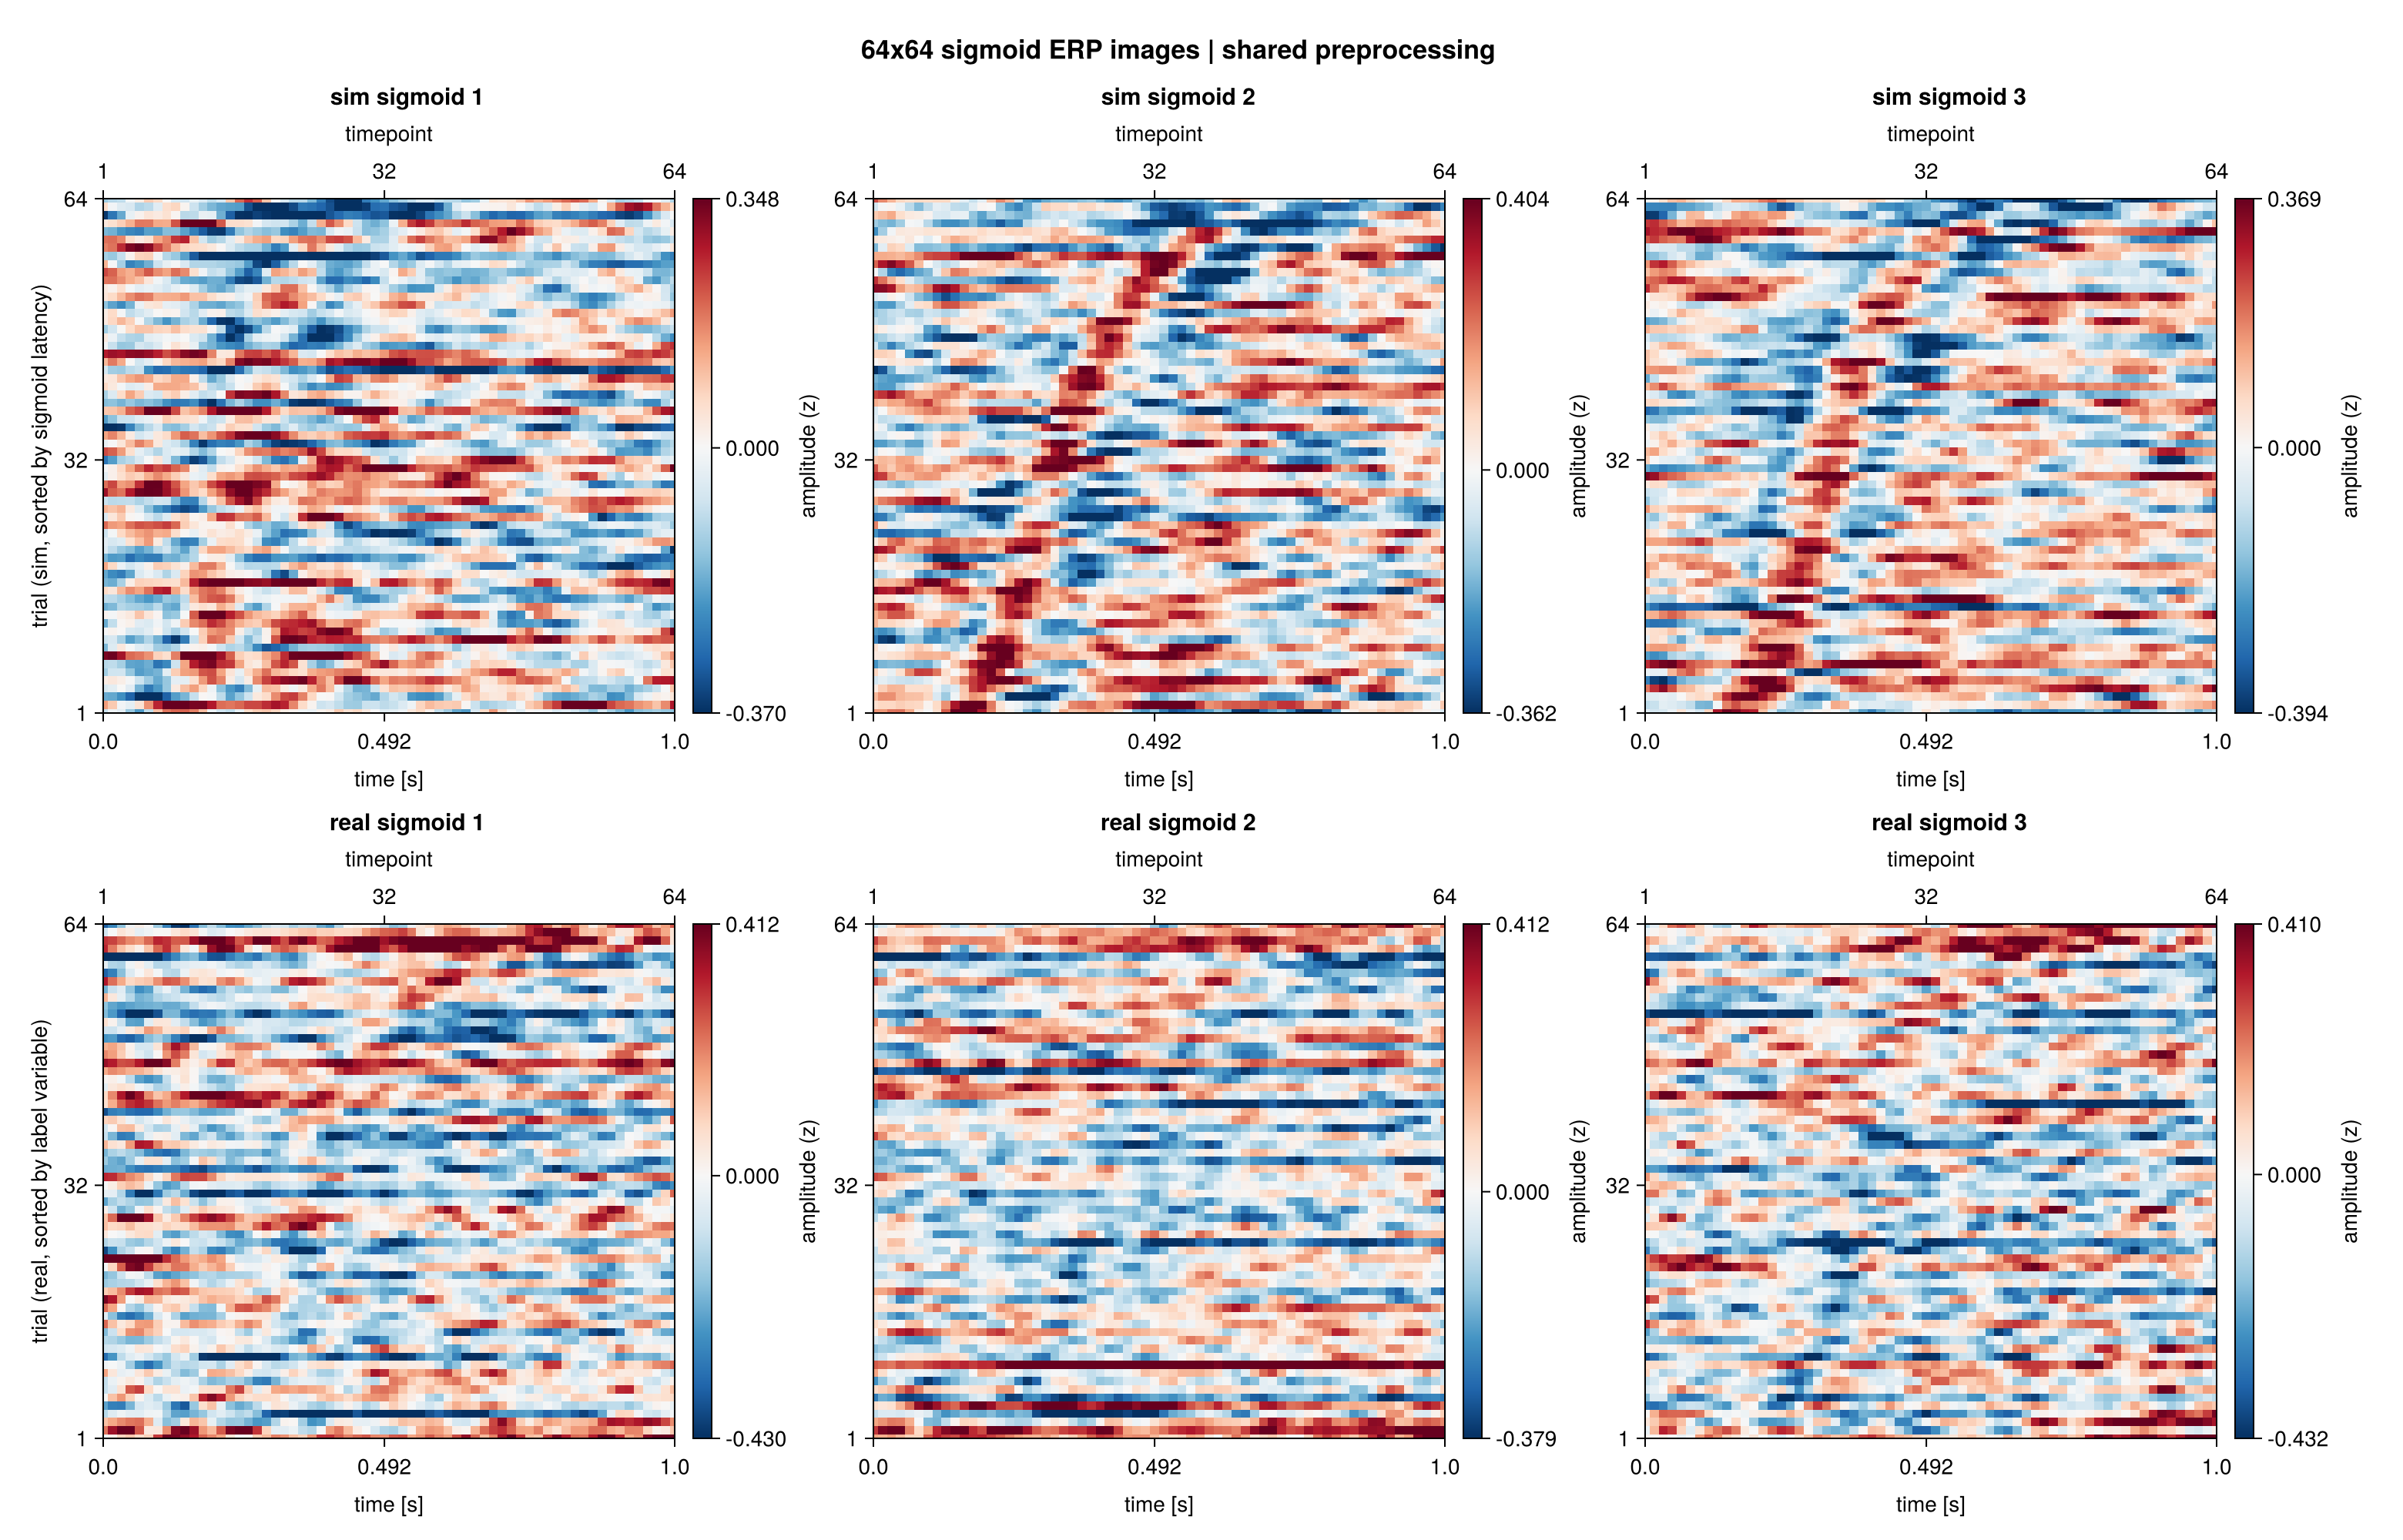

In [4]:

# ============================================================================
# Visual sanity check: simulated vs real sigmoid images
# ============================================================================

function derived_seed(parts...)
    h = UInt64(BASE_SEED)
    prime = UInt64(0x100000001b3)
    for part in parts
        for b in codeunits(string(part))
            h = (h ⊻ UInt64(b)) * prime
        end
        h = (h ⊻ UInt64(0xff)) * prime
    end
    return Int(mod(h, UInt64(typemax(Int) - 1))) + 1
end

function set_all_seeds!(seed::Integer)
    Random.seed!(seed)
    if USE_GPU && isdefined(CUDA, :seed!)
        try
            CUDA.seed!(seed)
        catch err
            @warn "CUDA.seed! failed; continuing after Random.seed!." exception = (err, catch_backtrace())
        end
    end
    return Random.Xoshiro(seed)
end

function cleanup_device!()
    GC.gc()
    USE_GPU && CUDA.reclaim()
    return nothing
end

device(x) = USE_GPU ? gpu(x) : x

function simulated_sort_column(events::DataFrame, pattern::Symbol, rng::AbstractRNG)
    if pattern == :sigmoid
        return collect(zip(events[!, ERPGenS.DELTA_LATENCY], events.latency))
    elseif pattern == :no_class
        return randperm(rng, nrow(events))
    end
    error("Unsupported simulated pattern: $(pattern)")
end

function preprocess_simulated_pattern(data_time_trials::AbstractMatrix, events::DataFrame, pattern::Symbol, rng::AbstractRNG)
    events_work = copy(events)
    events_work[!, :strategy_sort_key] = simulated_sort_column(events_work, pattern, rng)
    return preprocess_shared_image(data_time_trials, events_work, :strategy_sort_key)
end

function simulate_sigmoid_no_class_pair(cfg::ERPGenS.GenerationConfig, seed::Integer)
    set_all_seeds!(seed)
    rng = Random.Xoshiro(seed)
    raw = ERPGenS.simulate_raw_erp(cfg, rng)
    dropped = ERPGenS.apply_trial_dropout(raw.data, raw.events, cfg.processing, rng)
    cropped = ERPGenS.apply_cropping(dropped.data, cfg.processing, rng, raw.params.sampling_rate)
    data_time_trials = Float32.(cropped.data)
    events_trials = dropped.events
    @assert size(data_time_trials) == (REAL_N_TIMEPOINTS, REAL_N_TRIALS) "Simulated raw dimensions do not match fixations dataset dimensions."
    sigmoid_img = preprocess_simulated_pattern(data_time_trials, events_trials, :sigmoid, Random.Xoshiro(seed + 101))
    no_class_img = preprocess_simulated_pattern(data_time_trials, events_trials, :no_class, Random.Xoshiro(seed + 202))
    return sigmoid_img, no_class_img
end

function preview_simulated_sigmoids(cfg; n::Int = 3)
    imgs = Matrix{Float32}[]
    for i in 1:n
        sigmoid_img, _ = simulate_sigmoid_no_class_pair(cfg, derived_seed(:preview, i))
        push!(imgs, sigmoid_img)
    end
    return imgs
end

function preview_real_sigmoids(real_eval_df::DataFrame; n::Int = 3)
    idxs = findall(==(1), Int.(real_eval_df.binary_label))
    length(idxs) >= n || error("Need at least $(n) real sigmoid images for preview.")
    return [real_eval_df.processed_img[idxs[i]] for i in 1:n]
end

function add_explore_style_preview_panel!(fig, label_row::Int, axis_row::Int, col::Int, img::AbstractMatrix;
        title::AbstractString,
        row_label::AbstractString,
        sort_label::AbstractString,
        colormap_quantile::Float64 = 0.98)
    n_trials, n_timepoints = size(img)
    clipped, colorrange, tick_vals, tick_labels_text, _ = PlotProcessing.clipped_color_stats_quantile_zero_ticks(
        img;
        q_low = 1 - colormap_quantile,
        q_high = colormap_quantile,
    )
    vmin, vmax = colorrange
    cmap = PlotProcessing.make_diverging_cmap_zero_anchored(vmin, vmax)

    time_values = collect(range(0.0, REAL_EPOCH_DURATION_S; length = n_timepoints))
    time_tick_indices = PlotERP.axis_triplet(n_timepoints)
    time_tick_positions = time_values[time_tick_indices]
    time_tick_labels = PlotERP.tick_labels(time_tick_positions)
    timepoint_tick_labels = string.(time_tick_indices)
    y_tick_values = PlotERP.axis_triplet(n_trials)

    Label(fig[label_row, (2 * col - 1):(2 * col)], title;
        fontsize = 15,
        font = :bold,
        tellwidth = false,
        padding = (0, 0, 0, 4),
    )
    ax = Axis(fig[axis_row, 2 * col - 1];
        xlabel = "time [s]",
        ylabel = isempty(row_label) ? "" : "trial ($(row_label), sorted by $(sort_label))",
        xticks = (time_tick_positions, time_tick_labels),
        yticks = y_tick_values,
        xlabelpadding = 8,
        ylabelpadding = 8,
        xticklabelpad = 4,
        yticklabelpad = 4,
    )
    xlims!(ax, first(time_values), last(time_values))
    ylims!(ax, 1, n_trials)
    hm = heatmap!(
        ax,
        time_values,
        1:n_trials,
        Matrix{Float32}(permutedims(clipped, (2, 1)));
        colormap = cmap,
        colorrange = colorrange,
    )

    top_axis = Axis(fig[axis_row, 2 * col - 1];
        xaxisposition = :top,
        yaxisposition = :right,
        xlabel = "timepoint",
        xticks = (time_tick_positions, timepoint_tick_labels),
        backgroundcolor = (:white, 0.0),
        xlabelpadding = 8,
        xticklabelpad = 4,
    )
    linkxaxes!(ax, top_axis)
    xlims!(top_axis, first(time_values), last(time_values))
    hideydecorations!(top_axis)
    hidespines!(top_axis, :l, :r, :b)
    top_axis.ygridvisible = false
    top_axis.xgridvisible = false

    Colorbar(fig[axis_row, 2 * col], hm;
        label = "amplitude (z)",
        ticks = (tick_vals, tick_labels_text),
        width = 12,
    )
    return ax, hm
end

function plot_sim_vs_real_preview(sim_imgs, real_imgs; output_path::AbstractString)
    fig = Figure(size = (1560, 1000), figure_padding = (18, 28, 16, 14))
    Label(fig[0, 1:6], "64x64 sigmoid ERP images | shared preprocessing";
        fontsize = 17,
        font = :bold,
        tellwidth = false,
        padding = (0, 0, 0, 8),
    )
    for col in 1:3
        add_explore_style_preview_panel!(fig, 1, 2, col, sim_imgs[col];
            title = "sim sigmoid $(col)",
            row_label = col == 1 ? "sim" : "",
            sort_label = "sigmoid latency",
        )
        add_explore_style_preview_panel!(fig, 3, 4, col, real_imgs[col];
            title = "real sigmoid $(col)",
            row_label = col == 1 ? "real" : "",
            sort_label = "label variable",
        )
    end
    colgap!(fig.layout, 12)
    rowgap!(fig.layout, 8)
    resize_to_layout!(fig)
    mkpath(dirname(output_path))
    save(output_path, fig)
    return fig
end

sim_preview_imgs = preview_simulated_sigmoids(base_cfg; n = 3)
real_preview_imgs = preview_real_sigmoids(real_eval_df; n = 3)
preview_fig = plot_sim_vs_real_preview(sim_preview_imgs, real_preview_imgs; output_path = PREVIEW_PNG_PATH)
println("Saved preview figure: ", PREVIEW_PNG_PATH)
preview_fig


In [ ]:

# ============================================================================
# Strict sanity gate with fallback profiles
# ============================================================================

function smooth_onehot(y_oh::AbstractMatrix{<:Real}, epsilon::Real)
    epsilon <= 0 && return Array{Float32}(y_oh)
    n_classes = size(y_oh, 1)
    return Float32.((1 - epsilon) .* y_oh .+ epsilon / n_classes)
end

function weighted_logitcrossentropy(logits, y_oh, class_weights)
    logp = Flux.logsoftmax(logits; dims = 1)
    return mean(-sum(class_weights .* y_oh .* logp; dims = 1))
end

function build_resnet18_for_profile(profile)
    if profile.model_init == :pretrained
        model, matched = CNNUtils.build_resnet18_single_channel_pretrained(n_classes = 2, in_channels = 1)
        return model, matched
    elseif profile.model_init == :random
        model = CNNUtils.build_resnet18_single_channel_random(n_classes = 2, in_channels = 1)
        return model, 0
    end
    error("Unsupported model_init=$(profile.model_init).")
end

function generate_simulated_training_dataset(cfg::ERPGenS.GenerationConfig; n_per_pattern::Int, seed::Integer)
    imgs = Matrix{Float32}[]
    labels = Int[]
    for i in 1:n_per_pattern
        pair_seed = derived_seed(:sim_pair, seed, i)
        sigmoid_img, no_class_img = simulate_sigmoid_no_class_pair(cfg, pair_seed)
        push!(imgs, Float32.(sigmoid_img)); push!(labels, 1)
        push!(imgs, Float32.(no_class_img)); push!(labels, 0)
    end
    rng = Random.Xoshiro(derived_seed(:shuffle_training, seed))
    order = randperm(rng, length(labels))
    out = DataFrame(sample_id = 1:length(order), binary_label = labels[order])
    out.processed_img = imgs[order]
    return out
end

function train_resnet18!(model, X_train::Array{Float32, 4}, y_train::Vector{Int}, profile; run_tag::AbstractString)
    y_train_oh = onehotbatch(y_train, 0:1) |> Array{Float32}
    y_train_oh = smooth_onehot(y_train_oh, profile.label_smoothing)
    train_loader = DataLoader((X_train, y_train_oh); batchsize = profile.batchsize, shuffle = true)
    model = device(model)
    opt_state = Flux.setup(Flux.Adam(profile.lr), model)
    class_weights = device(reshape(Float32.(profile.class_weights), :, 1))
    Flux.trainmode!(model)

    train_time_s = @elapsed begin
        for epoch in 1:profile.nepochs
            running_loss = 0f0
            n_batches = 0
            for (xb_cpu, yb_cpu) in train_loader
                xb = device(xb_cpu)
                yb = device(yb_cpu)
                loss_val, grads = Flux.withgradient(model) do m
                    weighted_logitcrossentropy(m(xb), yb, class_weights)
                end
                opt_state, model = Flux.update!(opt_state, model, grads[1])
                running_loss += loss_val
                n_batches += 1
            end
            @info "$(run_tag) | epoch $(epoch)/$(profile.nepochs) | train_loss=$(@sprintf("%.5f", Float64(running_loss / max(1, n_batches))))"
        end
    end
    return model, Float64(train_time_s)
end

function binary_metrics(y_pred::Vector{Int}, y_true::Vector{Int})
    return (
        balanced_accuracy = StatisticalMeasures.BalancedAccuracy()(y_pred, y_true),
        macro_f1 = StatisticalMeasures.MulticlassFScore(; average = macro_avg)(y_pred, y_true),
    )
end

function evaluate_resnet18(model, X_val::Array{Float32, 4}, y_val::Vector{Int}; batchsize::Int)
    y_val_oh = onehotbatch(y_val, 0:1) |> Array{Float32}
    val_loader = DataLoader((X_val, y_val_oh); batchsize = batchsize, shuffle = false)
    Flux.testmode!(model)
    y_true = Int[]
    y_pred = Int[]
    classification_time_s = @elapsed begin
        for (xb_cpu, yb_cpu) in val_loader
            logits = cpu(model(device(xb_cpu)))
            append!(y_pred, onecold(logits, 0:1))
            append!(y_true, onecold(yb_cpu, 0:1))
        end
    end
    metrics = binary_metrics(y_pred, y_true)
    return metrics, y_true, y_pred, Float64(classification_time_s)
end

function required_predicted_class_count(n_validation::Integer)
    return ceil(Int, SANITY_CLASS_BALANCE_FRAC * Int(n_validation))
end

function is_noncollapsed_result(result)
    n_validation = result.true_count_0 + result.true_count_1
    min_pred = min(result.pred_count_0, result.pred_count_1)
    return result.balanced_accuracy >= SANITY_BACC_MIN && min_pred >= required_predicted_class_count(n_validation)
end

function train_and_score_candidate(cfg::ERPGenS.GenerationConfig, X_real, y_real, profile;
        n_per_pattern::Int,
        seed::Integer,
        run_tag::AbstractString)
    set_all_seeds!(seed)
    generation_time_s = @elapsed train_df = generate_simulated_training_dataset(cfg; n_per_pattern = n_per_pattern, seed = seed)
    X_train = CNNUtils.images_to_tensor(train_df.processed_img)
    y_train = Int.(train_df.binary_label)

    set_all_seeds!(derived_seed(:model_init, seed))
    model, pretrained_loaded = build_resnet18_for_profile(profile)
    model, train_time_s = train_resnet18!(model, X_train, y_train, profile; run_tag = run_tag)
    metrics, y_true, y_pred, classification_time_s = evaluate_resnet18(model, X_real, y_real; batchsize = profile.batchsize)

    result = (
        balanced_accuracy = Float64(metrics.balanced_accuracy),
        macro_f1 = Float64(metrics.macro_f1),
        train_time_s = train_time_s,
        classification_time_s = classification_time_s,
        generation_time_s = Float64(generation_time_s),
        n_train = length(y_train),
        n_val_real = length(y_true),
        train_pos = count(==(1), y_train),
        train_neg = count(==(0), y_train),
        pred_count_0 = count(==(0), y_pred),
        pred_count_1 = count(==(1), y_pred),
        true_count_0 = count(==(0), y_true),
        true_count_1 = count(==(1), y_true),
        pretrained_params_loaded = Int(pretrained_loaded),
        training_profile = String(profile.name),
        model_init = String(profile.model_init),
    )
    cleanup_device!()
    return merge(result, (collapsed = !is_noncollapsed_result(result),))
end

function run_sanity_gate()
    rows = NamedTuple[]
    for (profile_index, profile) in enumerate(TRAINING_PROFILES)
        println("\n=== Sanity profile $(profile_index)/$(length(TRAINING_PROFILES)): $(profile.name) ===")
        result = train_and_score_candidate(
            base_cfg,
            X_real,
            y_real,
            profile;
            n_per_pattern = N_PER_PATTERN,
            seed = derived_seed(:sanity, profile.name),
            run_tag = "sanity/$(profile.name)",
        )
        push!(rows, merge((profile_index = profile_index,), result))
        println("Sanity result | BAcc=", round(result.balanced_accuracy, digits = 4),
            " | macro_F1=", round(result.macro_f1, digits = 4),
            " | predicted no_class=", result.pred_count_0,
            " | predicted sigmoid=", result.pred_count_1,
            " | collapsed=", result.collapsed)
        if !result.collapsed
            return profile, DataFrame(rows)
        end
    end
    sanity_df = DataFrame(rows)
    show(sanity_df[:, [:profile_index, :training_profile, :balanced_accuracy, :macro_f1, :pred_count_0, :pred_count_1, :collapsed]], allrows = true, allcols = true)
    println()
    error("Strict sanity gate failed for every training profile. Refusing to run the strategy sweep or write CSV output.")
end

selected_profile, sanity_results_df = run_sanity_gate()
println("Selected training profile: ", selected_profile.name)



=== Sanity profile 1/4: pretrained_default ===


In [ ]:

# ============================================================================
# Baseline and strategy sweep
# ============================================================================

function params_for_candidate(method::Symbol, candidate_index::Int, rng::AbstractRNG, subset_indices::Vector{Int}, lhs_design)
    params = copy(base_params)
    if isempty(subset_indices)
        return params
    end
    if method == :latin_hypercube
        for (local_idx, global_idx) in enumerate(subset_indices)
            lo, hi = param_ranges[global_idx]
            params[global_idx] = lo + lhs_design[candidate_index, local_idx] * (hi - lo)
        end
    else
        sampled = SS.sample_param_vector(rng, param_ranges[subset_indices])
        for (local_idx, global_idx) in enumerate(subset_indices)
            params[global_idx] = sampled[local_idx]
        end
    end
    return params
end

function make_candidate_records(method::Symbol)
    cfg = STRATEGY_CONFIG[method]
    subset_indices = parameter_subset_indices(cfg.parameter_subset, param_symbols)
    n_candidates = Int(cfg.n_candidates)
    rng = Random.Xoshiro(derived_seed(:candidate_sampling, method))
    lhs_design = method == :latin_hypercube ? SS.latin_hypercube(n_candidates, length(subset_indices), rng) : nothing
    records = NamedTuple[]
    for candidate_index in 1:n_candidates
        params = params_for_candidate(method, candidate_index, rng, subset_indices, lhs_design)
        candidate_cfg = SS.build_cfg_from_params(base_cfg, params)
        push!(records, (
            search_method = String(method),
            candidate_index = candidate_index,
            cfg = candidate_cfg,
            params = Float64.(params),
            parameter_subset_size = length(subset_indices),
        ))
    end
    return records
end

baseline_record = (
    search_method = "baseline",
    candidate_index = 0,
    cfg = base_cfg,
    params = Float64.(base_params),
    parameter_subset_size = 0,
)

candidate_records = Dict(method => make_candidate_records(method) for method in keys(STRATEGY_CONFIG))
println("Candidate budgets: ", Dict(String(k) => length(v) for (k, v) in candidate_records))

function evaluate_record(record, repeats::Int)
    rows = NamedTuple[]
    for repeat_index in 1:repeats
        repeat_seed = derived_seed(:repeat, record.search_method, record.candidate_index, repeat_index)
        run_tag = "$(record.search_method)/candidate$(record.candidate_index)/repeat$(repeat_index)"
        println("\n=== $(run_tag) | seed=$(repeat_seed) ===")
        try
            result = train_and_score_candidate(
                record.cfg,
                X_real,
                y_real,
                selected_profile;
                n_per_pattern = N_PER_PATTERN,
                seed = repeat_seed,
                run_tag = run_tag,
            )
            push!(rows, merge((
                search_method = record.search_method,
                candidate_index = Int(record.candidate_index),
                repeat_index = repeat_index,
                repeat_seed = repeat_seed,
                parameter_subset_size = Int(record.parameter_subset_size),
            ), result))
        catch err
            @warn "Candidate repeat failed" search_method = record.search_method candidate_index = record.candidate_index repeat_index = repeat_index exception = (err, catch_backtrace())
            push!(rows, (
                search_method = record.search_method,
                candidate_index = Int(record.candidate_index),
                repeat_index = repeat_index,
                repeat_seed = repeat_seed,
                parameter_subset_size = Int(record.parameter_subset_size),
                balanced_accuracy = missing,
                macro_f1 = missing,
                train_time_s = missing,
                classification_time_s = missing,
                generation_time_s = missing,
                n_train = missing,
                n_val_real = missing,
                train_pos = missing,
                train_neg = missing,
                pred_count_0 = missing,
                pred_count_1 = missing,
                true_count_0 = missing,
                true_count_1 = missing,
                pretrained_params_loaded = missing,
                training_profile = String(selected_profile.name),
                model_init = String(selected_profile.model_init),
                collapsed = true,
                error_message = sprint(showerror, err),
            ))
            cleanup_device!()
        end
    end
    return DataFrame(rows)
end

function finite_values(xs)
    vals = Float64[]
    for x in xs
        if !ismissing(x)
            xf = Float64(x)
            isfinite(xf) && push!(vals, xf)
        end
    end
    return vals
end

mean_or_missing(xs) = isempty(finite_values(xs)) ? missing : mean(finite_values(xs))
function std_or_zero(xs)
    vals = finite_values(xs)
    return isempty(vals) ? missing : (length(vals) == 1 ? 0.0 : std(vals))
end

function aggregate_record(record, repeat_df::DataFrame; repeats::Int)
    valid_mask = [(!ismissing(row.balanced_accuracy)) && !Bool(row.collapsed) for row in eachrow(repeat_df)]
    valid_df = repeat_df[valid_mask, :]
    row_pairs = Pair{Symbol, Any}[
        :search_method => String(record.search_method),
        :candidate_index => Int(record.candidate_index),
        :balanced_accuracy_mean => mean_or_missing(valid_df.balanced_accuracy),
        :macro_f1_mean => mean_or_missing(valid_df.macro_f1),
        :balanced_accuracy_std => std_or_zero(valid_df.balanced_accuracy),
        :macro_f1_std => std_or_zero(valid_df.macro_f1),
        :train_time_s_mean => mean_or_missing(repeat_df.train_time_s),
        :classification_time_s_mean => mean_or_missing(repeat_df.classification_time_s),
        :n_valid_repeats => nrow(valid_df),
        :n_collapsed_repeats => count(Bool.(coalesce.(repeat_df.collapsed, true))),
        :eval_repeats => repeats,
        :n_per_pattern => N_PER_PATTERN,
        :training_profile => String(selected_profile.name),
        :model_init => String(selected_profile.model_init),
        :parameter_subset_size => Int(record.parameter_subset_size),
    ]
    append!(row_pairs, [param_symbols[j] => record.params[j] for j in eachindex(record.params)])
    return (; row_pairs...)
end

all_repeat_results = DataFrame[]
aggregate_rows = NamedTuple[]

println("\n=== Baseline base_cfg reference run ===")
baseline_repeats_df = evaluate_record(baseline_record, BASELINE_REPEATS)
push!(all_repeat_results, baseline_repeats_df)
push!(aggregate_rows, aggregate_record(baseline_record, baseline_repeats_df; repeats = BASELINE_REPEATS))

for method in [:broad_random, :latin_hypercube, :monte_carlo]
    println("\n==============================")
    println("Strategy: ", method)
    println("==============================")
    for record in candidate_records[method]
        repeat_df = evaluate_record(record, EVAL_REPEATS)
        push!(all_repeat_results, repeat_df)
        push!(aggregate_rows, aggregate_record(record, repeat_df; repeats = EVAL_REPEATS))
    end
end

repeat_results_df = vcat(all_repeat_results...; cols = :union)
strategy_results_df = DataFrame(aggregate_rows)
sort!(strategy_results_df, [:search_method, :candidate_index])

println("\nSweep complete. Candidate summary:")
show(strategy_results_df[:, [:search_method, :candidate_index, :balanced_accuracy_mean, :macro_f1_mean, :balanced_accuracy_std, :train_time_s_mean, :classification_time_s_mean, :n_valid_repeats, :n_collapsed_repeats]], allrows = true, allcols = true)
println()


In [ ]:

# ============================================================================
# Select best overall run, write best_run.csv, and print summary
# ============================================================================

function eligible_strategy_rows(results_df::DataFrame)
    method_names = String.([:broad_random, :latin_hypercube, :monte_carlo])
    df = copy(results_df[in.(results_df.search_method, Ref(method_names)), :])
    df = df[.!ismissing.(df.balanced_accuracy_mean) .& .!ismissing.(df.macro_f1_mean), :]
    return df
end

function strategy_top_rows(results_df::DataFrame)
    rows = NamedTuple[]
    for method in String.([:broad_random, :latin_hypercube, :monte_carlo])
        df = copy(results_df[results_df.search_method .== method, :])
        df = df[.!ismissing.(df.balanced_accuracy_mean) .& .!ismissing.(df.macro_f1_mean), :]
        if nrow(df) == 0
            push!(rows, (
                search_method = method,
                candidate_index = missing,
                balanced_accuracy_mean = missing,
                macro_f1_mean = missing,
                train_time_s_mean = missing,
                classification_time_s_mean = missing,
                n_valid_repeats = 0,
            ))
        else
            sort!(df, [:balanced_accuracy_mean, :macro_f1_mean]; rev = [true, true])
            r = df[1, :]
            push!(rows, (
                search_method = String(r.search_method),
                candidate_index = Int(r.candidate_index),
                balanced_accuracy_mean = Float64(r.balanced_accuracy_mean),
                macro_f1_mean = Float64(r.macro_f1_mean),
                train_time_s_mean = Float64(r.train_time_s_mean),
                classification_time_s_mean = Float64(r.classification_time_s_mean),
                n_valid_repeats = Int(r.n_valid_repeats),
            ))
        end
    end
    return DataFrame(rows)
end

eligible_df = eligible_strategy_rows(strategy_results_df)
nrow(eligible_df) > 0 || error("No strategy candidate passed the collapse filter. Refusing to write best_run.csv.")
sort!(eligible_df, [:balanced_accuracy_mean, :macro_f1_mean]; rev = [true, true])
best_row = eligible_df[1, :]

best_pairs = Pair{Symbol, Any}[
    :search_method => String(best_row.search_method),
    :candidate_index => Int(best_row.candidate_index),
    :balanced_accuracy_mean => Float64(best_row.balanced_accuracy_mean),
    :macro_f1_mean => Float64(best_row.macro_f1_mean),
    :balanced_accuracy_std => Float64(best_row.balanced_accuracy_std),
    :train_time_s_mean => Float64(best_row.train_time_s_mean),
    :classification_time_s_mean => Float64(best_row.classification_time_s_mean),
]
append!(best_pairs, [param_symbols[j] => Float64(best_row[param_symbols[j]]) for j in eachindex(param_symbols)])
best_run_df = DataFrame([(; best_pairs...)])

mkpath(OUTPUT_DIR)
for path in readdir(OUTPUT_DIR; join = true)
    isfile(path) && endswith(path, ".csv") && rm(path; force = true)
end
CSV.write(BEST_RUN_CSV_PATH, best_run_df)

println("\nPer-strategy top results:")
top_df = strategy_top_rows(strategy_results_df)
for row in eachrow(top_df)
    if ismissing(row.candidate_index)
        println("  ", row.search_method, ": no non-collapsed candidate")
    else
        println("  ", row.search_method,
            ": candidate=", row.candidate_index,
            " | BAcc=", round(row.balanced_accuracy_mean, digits = 4),
            " | macro_F1=", round(row.macro_f1_mean, digits = 4),
            " | train_time_s=", round(row.train_time_s_mean, digits = 2),
            " | classification_time_s=", round(row.classification_time_s_mean, digits = 4),
            " | valid_repeats=", row.n_valid_repeats)
    end
end

println("\nOverall winner:")
println("  search_method=", best_run_df.search_method[1],
    " | candidate_index=", best_run_df.candidate_index[1],
    " | balanced_accuracy_mean=", round(best_run_df.balanced_accuracy_mean[1], digits = 4),
    " | macro_f1_mean=", round(best_run_df.macro_f1_mean[1], digits = 4),
    " | train_time_s_mean=", round(best_run_df.train_time_s_mean[1], digits = 2),
    " | classification_time_s_mean=", round(best_run_df.classification_time_s_mean[1], digits = 4))
println("\nWinner parameters:")
for sym in param_symbols
    println("  ", sym, " = ", best_run_df[1, sym])
end
println("\nWrote CSV: ", BEST_RUN_CSV_PATH)
best_run_df
